In [1]:
import random
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Softmax
from tensorflow.keras.applications import MobileNetV2
import tensorflow_datasets as tfds

from sklearn.model_selection import train_test_split
import pandas as pd
import cv2
import glob
import matplotlib.pyplot as plt

print(tf.__version__)

2.2.0


In [2]:
INPUT_DIM = 224
N_OUTPUT = 120

In [3]:
# get datasets
def __rescale(sample):
    sample['image'] /= 255
    return sample

def __resize(sample):    
    sample['image'] = tf.image.resize_with_pad(sample['image'], INPUT_DIM, INPUT_DIM)
    return sample

def __random_flips(sample):
    sample['image'] = tf.image.random_flip_left_right(sample['image'])    
    sample['image'] = tf.image.random_flip_up_down(sample['image'])
    return sample

def __prepare_output(sample):
    return sample['image'], sample['label']


(train_ds, test_ds), info = tfds.load('stanford_dogs', split=['train', 'test'], with_info=True)

train_ds = train_ds.map(__rescale)
train_ds = train_ds.map(__resize)
train_ds = train_ds.map(__random_flips)
train_ds = train_ds.map(__prepare_output)

test_ds = test_ds.map(__rescale)
test_ds = test_ds.map(__resize)
test_ds = test_ds.map(__prepare_output)

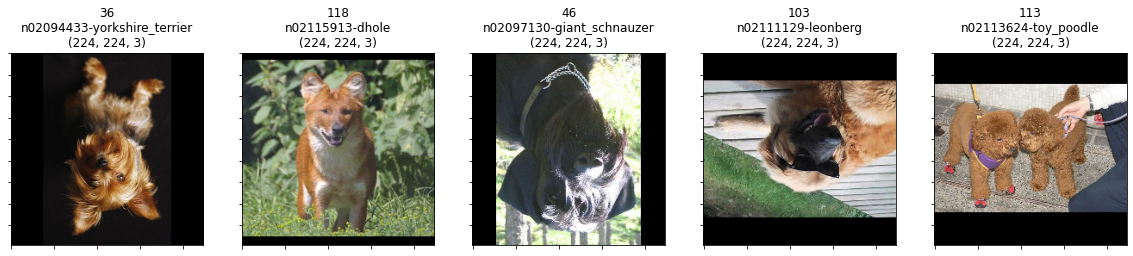

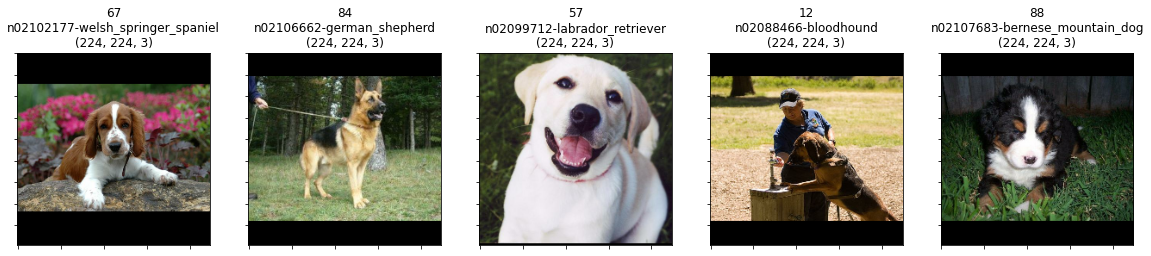

In [4]:
def plot_examples(dataset, info, n=5):
    fig, axs = plt.subplots(1, n, figsize=(20,5))
    
    for i, (img, label) in enumerate(dataset.take(n)):        
        axs[i].imshow(img)
        name = info.features['label'].names[label]
        axs[i].set_title(f'{label}\n{name}\n{img.shape}')

        axs[i].set_xticklabels([])
        axs[i].set_yticklabels([])
    plt.show()
    
plot_examples(train_ds, info)
plot_examples(test_ds, info)

# Network

In [7]:
# Create a sequential NN
model = keras.models.Sequential()

# Start with a mobilnet backbone
mobilenet = MobileNetV2(
    input_shape=(INPUT_DIM, INPUT_DIM, 3),
    alpha=1.0,
    include_top=False,
    weights=None,
    input_tensor=None,
    pooling='avg',
    classes=None,
    classifier_activation=None
)
model.add(mobilenet)

# Add the output layers
model.add(Dense(1000, activation='relu'))
model.add(Dense(N_OUTPUT, activation='relu'))
model.add(Softmax())

# Loss
scce = tf.keras.losses.SparseCategoricalCrossentropy()

# model = MobileNetV2(input_shape=(INPUT_DIM, INPUT_DIM, 3), classes=120, include_top=True, weights=None)

# Compile
model.compile(loss=scce, optimizer='adam')

In [8]:
model.fit(
    x = train_ds.shuffle(500).batch(16, drop_remainder=True),
    validation_data = test_ds.shuffle(500).batch(16, drop_remainder=True),
    epochs=100
)

 39/750 [>.............................] - ETA: 28:15 - loss: 4.8398

KeyboardInterrupt: 

In [ ]:
# X = []
# y = []

# for sample in train_ds.take(1000):
#     X.append(sample['image'])
#     y.append(sample['label'])
    
# X = np.array(X)
# y = np.array(y)

# model.fit(x=X, y=y)